**Introduction to Computer Vision**

subject : pothole detector

team ->
Chedammi Reena 14918 &
Ramgoelam Ashitosh 14934

Install Required Libraries

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.4 MB/s eta 0:00:00


Extract the Dataset

In [1]:
!unzip "archive (5).zip"

Archive:  archive (5).zip
  inflating: annotations/potholes0.xml  
  inflating: annotations/potholes1.xml  
  inflating: annotations/potholes10.xml  
  inflating: annotations/potholes100.xml  
  inflating: annotations/potholes101.xml  
  inflating: annotations/potholes102.xml  
  inflating: annotations/potholes103.xml  
  inflating: annotations/potholes104.xml  
  inflating: annotations/potholes105.xml  
  inflating: annotations/potholes106.xml  
  inflating: annotations/potholes107.xml  
  inflating: annotations/potholes108.xml  
  inflating: annotations/potholes109.xml  
  inflating: annotations/potholes11.xml  
  inflating: annotations/potholes110.xml  
  inflating: annotations/potholes111.xml  
  inflating: annotations/potholes112.xml  
  inflating: annotations/potholes113.xml  
  inflating: annotations/potholes114.xml  
  inflating: annotations/potholes115.xml  
  inflating: annotations/potholes116.xml  
  inflating: annotations/potholes117.xml  
  inflating: annotations/potholes1

Verify Extracted Files

In [2]:
!ls

 annotations  'archive (5).zip'   images   sample_data


List Images in Dataset

In [3]:
!ls images

potholes0.png	 potholes250.png  potholes400.png  potholes551.png
potholes100.png  potholes251.png  potholes401.png  potholes552.png
potholes101.png  potholes252.png  potholes402.png  potholes553.png
potholes102.png  potholes253.png  potholes403.png  potholes554.png
potholes103.png  potholes254.png  potholes404.png  potholes555.png
potholes104.png  potholes255.png  potholes405.png  potholes556.png
potholes105.png  potholes256.png  potholes406.png  potholes557.png
potholes106.png  potholes257.png  potholes407.png  potholes558.png
potholes107.png  potholes258.png  potholes408.png  potholes559.png
potholes108.png  potholes259.png  potholes409.png  potholes55.png
potholes109.png  potholes25.png   potholes40.png   potholes560.png
potholes10.png	 potholes260.png  potholes410.png  potholes561.png
potholes110.png  potholes261.png  potholes411.png  potholes562.png
potholes111.png  potholes262.png  potholes412.png  potholes563.png
potholes112.png  potholes263.png  potholes413.png  potholes564.png

List Annotation Files

In [4]:
!ls annotations

potholes0.xml	 potholes250.xml  potholes400.xml  potholes551.xml
potholes100.xml  potholes251.xml  potholes401.xml  potholes552.xml
potholes101.xml  potholes252.xml  potholes402.xml  potholes553.xml
potholes102.xml  potholes253.xml  potholes403.xml  potholes554.xml
potholes103.xml  potholes254.xml  potholes404.xml  potholes555.xml
potholes104.xml  potholes255.xml  potholes405.xml  potholes556.xml
potholes105.xml  potholes256.xml  potholes406.xml  potholes557.xml
potholes106.xml  potholes257.xml  potholes407.xml  potholes558.xml
potholes107.xml  potholes258.xml  potholes408.xml  potholes559.xml
potholes108.xml  potholes259.xml  potholes409.xml  potholes55.xml
potholes109.xml  potholes25.xml   potholes40.xml   potholes560.xml
potholes10.xml	 potholes260.xml  potholes410.xml  potholes561.xml
potholes110.xml  potholes261.xml  potholes411.xml  potholes562.xml
potholes111.xml  potholes262.xml  potholes412.xml  potholes563.xml
potholes112.xml  potholes263.xml  potholes413.xml  potholes564.xml

Install YOLO Library

In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.3 MB/s eta 0:00:00


Convert XML Annotations to YOLO Labels

In [6]:
import os
import xml.etree.ElementTree as ET

images_path = "images"
annotations_path = "annotations"

os.makedirs("labels", exist_ok=True)

for xml_file in os.listdir(annotations_path):

    tree = ET.parse(os.path.join(annotations_path, xml_file))
    root = tree.getroot()

    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    label_file = open("labels/" + xml_file.replace(".xml",".txt"), "w")

    for obj in root.findall("object"):

        box = obj.find("bndbox")

        xmin = int(box.find("xmin").text)
        ymin = int(box.find("ymin").text)
        xmax = int(box.find("xmax").text)
        ymax = int(box.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / width
        y_center = ((ymin + ymax) / 2) / height
        w = (xmax - xmin) / width
        h = (ymax - ymin) / height

        label_file.write(f"0 {x_center} {y_center} {w} {h}\n")

    label_file.close()

print("Conversion complete!")

Conversion complete!


Create YOLO Dataset Configuration (data.yaml)

In [7]:
with open("data.yaml", "w") as f:
    f.write("""
train: images
val: images

nc: 1
names: ['pothole']
""")

Split Dataset into Train and Validation (80/20)

In [12]:
import os
import random
import shutil

# create folders
os.makedirs("images/train", exist_ok=True)
os.makedirs("images/val", exist_ok=True)
os.makedirs("labels/train", exist_ok=True)
os.makedirs("labels/val", exist_ok=True)

# get png images
images = [f for f in os.listdir("images") if f.endswith(".png")]

random.shuffle(images)

split_index = int(len(images) * 0.8)

train_files = images[:split_index]
val_files = images[split_index:]

for file in train_files:
    shutil.move(f"images/{file}", f"images/train/{file}")
    shutil.move(f"labels/{file.replace('.png','.txt')}", f"labels/train/{file.replace('.png','.txt')}")

for file in val_files:
    shutil.move(f"images/{file}", f"images/val/{file}")
    shutil.move(f"labels/{file.replace('.png','.txt')}", f"labels/val/{file.replace('.png','.txt')}")

print("Dataset split successfully!")

Dataset split successfully!


Preview Training Images

In [13]:
!ls images/train | head

potholes0.png
potholes100.png
potholes101.png
potholes102.png
potholes104.png
potholes105.png
potholes106.png
potholes107.png
potholes108.png
potholes10.png


Preview Validation Images

In [14]:
!ls images/val | head

potholes103.png
potholes109.png
potholes111.png
potholes117.png
potholes118.png
potholes121.png
potholes141.png
potholes143.png
potholes144.png
potholes145.png


Train YOLOv8 Pothole Detection Model

In [15]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="data.yaml",
    epochs=10,
    imgsz=640
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ef50653b770>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Test Model on Validation Image

In [18]:
model.predict("images/val/potholes103.png", save=True)


image 1/1 /content/images/val/potholes103.png: 416x640 1 pothole, 199.8ms
Speed: 6.8ms preprocess, 199.8ms inference, 4.5ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'pothole'}
 obb: None
 orig_img: array([[[ 28,  57,  48],
         [ 38,  67,  58],
         [ 42,  73,  64],
         ...,
         [102,  99,  95],
         [ 99,  96,  92],
         [ 95,  92,  88]],
 
        [[ 33,  62,  53],
         [ 45,  74,  65],
         [ 45,  76,  67],
         ...,
         [112, 109, 105],
         [110, 107, 103],
         [108, 105, 101]],
 
        [[ 39,  65,  59],
         [ 40,  66,  60],
         [ 39,  67,  61],
         ...,
         [107, 104, 100],
         [107, 104, 100],
         [106, 103,  99]],
 
        ...,
 
        [[ 39,  37,  36],
         [ 47,  45,  44],
         [ 49,  47,  46],
         ...,
         [ 51,  48,  44],
         [ 54,  51,  47],
         [ 58,  55,  51]],
 
        [[ 38,  36,  35],
         [ 46,  44,  43],
         [ 48,  46,  45],
         ...,
         [ 50,  4

test on 1 imag

In [20]:
!ls runs/detect/predict

potholes103.jpg


In [22]:
!ls runs/detect

predict  train	train2


In [23]:
!ls runs/detect/predict

potholes103.jpg


In [25]:
!ls runs/detect/predict

potholes103.jpg


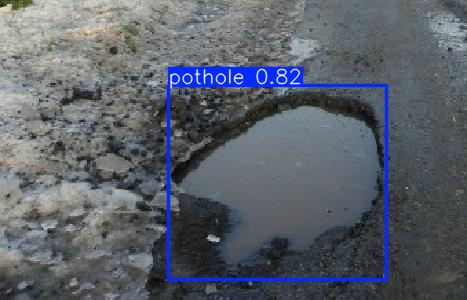

In [26]:
from IPython.display import Image
Image("runs/detect/predict/potholes103.jpg")

Run Detection on Validation Dataset

In [27]:
model.predict("images/val", save=True)


image 1/133 /content/images/val/potholes103.png: 416x640 1 pothole, 148.5ms
image 2/133 /content/images/val/potholes109.png: 288x640 5 potholes, 143.8ms
image 3/133 /content/images/val/potholes111.png: 640x640 2 potholes, 267.3ms
image 4/133 /content/images/val/potholes117.png: 640x640 2 potholes, 228.2ms
image 5/133 /content/images/val/potholes118.png: 640x640 1 pothole, 210.4ms
image 6/133 /content/images/val/potholes121.png: 384x640 9 potholes, 161.5ms
image 7/133 /content/images/val/potholes14.png: 640x640 4 potholes, 225.6ms
image 8/133 /content/images/val/potholes141.png: 448x640 1 pothole, 165.7ms
image 9/133 /content/images/val/potholes143.png: 384x640 2 potholes, 130.9ms
image 10/133 /content/images/val/potholes144.png: 480x640 8 potholes, 199.6ms
image 11/133 /content/images/val/potholes145.png: 384x640 5 potholes, 134.2ms
image 12/133 /content/images/val/potholes147.png: 448x640 2 potholes, 152.6ms
image 13/133 /content/images/val/potholes151.png: 544x640 1 pothole, 231.5ms

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'pothole'}
 obb: None
 orig_img: array([[[ 28,  57,  48],
         [ 38,  67,  58],
         [ 42,  73,  64],
         ...,
         [102,  99,  95],
         [ 99,  96,  92],
         [ 95,  92,  88]],
 
        [[ 33,  62,  53],
         [ 45,  74,  65],
         [ 45,  76,  67],
         ...,
         [112, 109, 105],
         [110, 107, 103],
         [108, 105, 101]],
 
        [[ 39,  65,  59],
         [ 40,  66,  60],
         [ 39,  67,  61],
         ...,
         [107, 104, 100],
         [107, 104, 100],
         [106, 103,  99]],
 
        ...,
 
        [[ 39,  37,  36],
         [ 47,  45,  44],
         [ 49,  47,  46],
         ...,
         [ 51,  48,  44],
         [ 54,  51,  47],
         [ 58,  55,  51]],
 
        [[ 38,  36,  35],
         [ 46,  44,  43],
         [ 48,  46,  45],
         ...,
         [ 50,  4

checking images

In [17]:
!ls images/val | head

potholes103.png
potholes109.png
potholes111.png
potholes117.png
potholes118.png
potholes121.png
potholes141.png
potholes143.png
potholes144.png
potholes145.png


In [ ]:
!ls images/val | head

potholes103.png
potholes109.png
potholes111.png
potholes117.png
potholes118.png
potholes121.png
potholes141.png
potholes143.png
potholes144.png
potholes145.png


List Image Files

In [11]:
!ls images

potholes0.png	 potholes250.png  potholes400.png  potholes551.png
potholes100.png  potholes251.png  potholes401.png  potholes552.png
potholes101.png  potholes252.png  potholes402.png  potholes553.png
potholes102.png  potholes253.png  potholes403.png  potholes554.png
potholes103.png  potholes254.png  potholes404.png  potholes555.png
potholes104.png  potholes255.png  potholes405.png  potholes556.png
potholes105.png  potholes256.png  potholes406.png  potholes557.png
potholes106.png  potholes257.png  potholes407.png  potholes558.png
potholes107.png  potholes258.png  potholes408.png  potholes559.png
potholes108.png  potholes259.png  potholes409.png  potholes55.png
potholes109.png  potholes25.png   potholes40.png   potholes560.png
potholes10.png	 potholes260.png  potholes410.png  potholes561.png
potholes110.png  potholes261.png  potholes411.png  potholes562.png
potholes111.png  potholes262.png  potholes412.png  potholes563.png
potholes112.png  potholes263.png  potholes413.png  potholes564.png

Test Model on Custom Image

In [28]:
model.predict("test image.jpg", save=True)


image 1/1 /content/test image.jpg: 448x640 1 pothole, 162.8ms
Speed: 5.4ms preprocess, 162.8ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'pothole'}
 obb: None
 orig_img: array([[[169, 137, 124],
         [163, 133, 122],
         [159, 134, 124],
         ...,
         [187, 179, 179],
         [189, 181, 181],
         [193, 185, 185]],
 
        [[136, 146, 156],
         [114, 126, 138],
         [ 97, 114, 127],
         ...,
         [204, 196, 196],
         [202, 194, 194],
         [200, 192, 192]],
 
        [[ 85, 137, 173],
         [ 66, 119, 156],
         [ 57, 114, 153],
         ...,
         [201, 193, 193],
         [195, 187, 187],
         [184, 176, 176]],
 
        ...,
 
        [[ 66,  53,  55],
         [110,  97,  99],
         [134, 123, 125],
         ...,
         [109, 115, 128],
         [ 95, 101, 114],
         [ 82,  88, 101]],
 
        [[110,  99, 101],
         [140, 129, 131],
         [145, 137, 138],
         ...,
         [100, 10

Display Detection Result

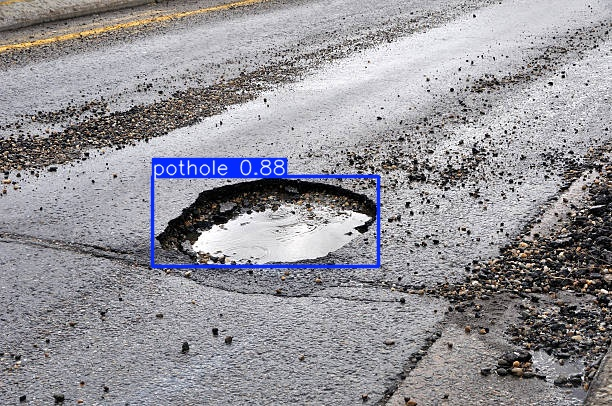

In [29]:
from IPython.display import Image
Image("runs/detect/predict/test image.jpg")

Run Detection on Custom Video

In [30]:
model.predict("test vid.mp4", save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/487) /content/test vid.mp4: 448x640 (no detections), 176.0ms
video 1/1 (frame 2/487) /content/test vid.mp4: 448x640 (no detections), 153.4ms
video 1/1 (frame 3/487) /content/test vid.mp4: 448x640 (no detections), 160.1ms
video 1/1 (frame 4/487) /content/test vid.mp4: 448x640 (no detections), 146.7ms
video 1/1 (frame 5/487) /content/test vid.mp4: 448x640 (no detections), 153.2ms
video 1/1 (frame 6/487) /content/test vid.mp4: 448x640 (no

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'pothole'}
 obb: None
 orig_img: array([[[252, 255, 255],
         [252, 255, 255],
         [252, 255, 255],
         ...,
         [ 39,  49,  48],
         [ 43,  54,  48],
         [ 43,  54,  48]],
 
        [[252, 255, 255],
         [252, 255, 255],
         [252, 255, 255],
         ...,
         [ 37,  47,  46],
         [ 41,  52,  46],
         [ 41,  52,  46]],
 
        [[252, 255, 255],
         [252, 255, 255],
         [252, 255, 255],
         ...,
         [ 32,  44,  43],
         [ 38,  49,  43],
         [ 41,  52,  46]],
 
        ...,
 
        [[ 15,  12,  13],
         [ 15,  12,  13],
         [ 15,  12,  13],
         ...,
         [  8,   5,   6],
         [  5,   5,   5],
         [  5,   5,   5]],
 
        [[ 14,  11,  12],
         [ 14,  11,  12],
         [ 14,  11,  12],
         ...,
         [  7,   

List Prediction Output Files

In [31]:
!ls runs/detect/predict

 potholes103.jpg   potholes265.jpg   potholes423.jpg   potholes585.jpg
 potholes109.jpg   potholes279.jpg   potholes425.jpg   potholes590.jpg
 potholes111.jpg   potholes281.jpg   potholes426.jpg   potholes591.jpg
 potholes117.jpg   potholes283.jpg   potholes42.jpg    potholes595.jpg
 potholes118.jpg   potholes287.jpg   potholes432.jpg   potholes598.jpg
 potholes121.jpg   potholes296.jpg   potholes433.jpg   potholes601.jpg
 potholes141.jpg   potholes299.jpg   potholes448.jpg   potholes603.jpg
 potholes143.jpg   potholes2.jpg     potholes452.jpg   potholes606.jpg
 potholes144.jpg   potholes30.jpg    potholes45.jpg    potholes607.jpg
 potholes145.jpg   potholes312.jpg   potholes461.jpg   potholes60.jpg
 potholes147.jpg   potholes321.jpg   potholes462.jpg   potholes613.jpg
 potholes14.jpg    potholes322.jpg   potholes479.jpg   potholes617.jpg
 potholes151.jpg   potholes325.jpg   potholes480.jpg   potholes61.jpg
 potholes153.jpg   potholes32.jpg    potholes485.jpg   potholes625.jpg
 pothole

Finally, we downloaded the processed video from the runs/detect/predict folder and played it on the computer to view the pothole detection results.